## Graph Attention Networks on undirected graph

In [1]:
import sys
sys.path.insert(0, "./")
from dataAnalysis.DataAnalysis import DataAnalysis
import pandas as pd
import numpy as np
import torch
 

data = pd.read_csv(r"./extdata/sbcdata.csv", header=0)
data_analysis = DataAnalysis(data)

/home/dwalke/git/sbc_app/./dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Label'] = self.data['Diagnosis']
/home/dwalke/git/sbc_app/./dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Label'] = self.data['Diagnosis']
/home/dwalke/git/sbc_app/./dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

## Sort data based on ID for matching edge index

In [2]:
data = pd.concat((data_analysis.get_training_data(), data_analysis.get_testing_data()))
max_Id = data["Id"].unique().max()
gw_data = data_analysis.get_gw_testing_data().copy(deep=True)
gw_data = gw_data.assign(Id=lambda x: x.Id + max_Id)
data = pd.concat((data, gw_data))
data = data.sort_values(["Id", "Time"])
data = data.reset_index(drop=True)
popped_index = data.pop("index")

## Reading edge index

In [3]:
edge_index = torch.tensor(pd.read_csv("edge_index/reverse_directed_edge_index.csv", header=None, skiprows=1).values.transpose(), dtype=torch.long)

## Pre-processing categorical variables

In [4]:
from dataAnalysis.Constants import SEX_CATEGORY_COLUMN_NAME, SEX_COLUMN_NAME, FEATURES
data[SEX_CATEGORY_COLUMN_NAME] = data.loc[:, SEX_COLUMN_NAME] =="W"

data[SEX_CATEGORY_COLUMN_NAME] = data[SEX_CATEGORY_COLUMN_NAME].astype("int8")
data["Label"] = data["Label"] == "Sepsis"
data["Label"] = data["Label"].astype("int8")

## Set features and labels

In [5]:
X_features = torch.tensor(data[FEATURES].values).type(torch.float32)
y = torch.tensor(data["Label"].values).type(torch.long)

## Normalize data

In [6]:
from dataAnalysis.FeatureImportance import normalize

X_features = normalize(X_features)

## Reading and adding positional encodings

In [7]:
pos_encodings = pd.read_csv("positional_encodings/positional_encodings.csv", header=None, skiprows=1)

pos_encodings = pos_encodings.values

In [8]:
X_features

tensor([[ 1.1067, -0.9899,  0.4046,  ...,  0.3607, -0.4256, -0.6549],
        [-1.2956, -0.9899,  2.0656,  ...,  2.3851, -1.3951, -0.3717],
        [-0.6404,  1.0102,  0.8033,  ...,  0.3729,  0.1943,  0.5042],
        ...,
        [-0.1490, -0.9899,  0.4046,  ...,  0.5314, -0.1713, -0.1417],
        [ 0.0693,  1.0102,  1.0690,  ...,  0.8973,  0.2102,  0.8493],
        [ 0.0693,  1.0102,  1.4676,  ...,  1.3851,  0.4804,  1.1501]])

In [9]:
X_new_features = X_features + pos_encodings

## Create train, validation and test masks

In [10]:
def ratio_bool_switch(tensor, ratio = 0.8):
    random = np.random.uniform(0, 1 ,tensor.shape[0])
    val_ratio_mask = (random >= 0.8)
    train_ratio_mask = (random < 0.8)
    val_mask = np.logical_and(tensor.tolist(), val_ratio_mask.tolist())
    train_mask = np.logical_and(tensor.tolist(), train_ratio_mask.tolist())
    return torch.from_numpy(train_mask).type(torch.bool), torch.from_numpy(val_mask).type(torch.bool)

In [11]:
train_mask_ser = data["Set"] != "Validation"
train_mask, val_mask = ratio_bool_switch(train_mask_ser.values)
test_mask = torch.from_numpy(np.logical_and((data["Set"] == "Validation").values, (data["Center"] == "Leipzig").values)).type(torch.bool)
test_gw_mask = torch.from_numpy(np.logical_and((data["Set"] == "Validation").values, (data["Center"] == "Greifswald").values)).type(torch.bool)

## Create patient-centric graph

In [12]:
from torch_geometric.data import Data

graph = Data(x=X_new_features, train_mask = train_mask, test_mask=test_mask, val_mask=val_mask, y= y, edge_index=edge_index,
             test_gw_mask = test_gw_mask)

## Create graph batches

In [13]:
from torch_geometric.loader import NeighborLoader

kwargs = {
    "num_neighbors":[-1] * 2,
    "batch_size":50_000,
}
loader = NeighborLoader(
    graph,
    input_nodes=graph.train_mask,
    **kwargs
)
val_loader = NeighborLoader(
    graph,
    input_nodes=graph.val_mask,
    **kwargs
)

## Set device

In [50]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")

graph = graph.to(device)
WEIGHT = torch.tensor([530])
WEIGHT = WEIGHT.to(device)

print("Data shifted to the device " + str(device))

Data shifted to the device cuda:1


## Define the model

In [51]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv,GATv2Conv, GINConv, SAGEConv
from dataAnalysis.Constants import FEATURES
from torch.nn import Linear, ReLU, Sequential
from torch.nn import BatchNorm1d as BatchNorm

class GraphNeuralNetwork(torch.nn.Module):
    def __init__(self, hidden_dim = 128, out_channels = 1):
        super(GraphNeuralNetwork, self).__init__()
        input_dim = len(FEATURES)      
        
        HEADS = 5
        
        conv_1= GATConv(input_dim, hidden_dim,heads=HEADS, add_self_loops = False)
        conv_end = GATConv((-1,-1), out_channels,add_self_loops = False)
        
        self.conv_1 = conv_1
        self.conv_end = conv_end
        

    def forward(self, x, edge_index):
        # x, edge_index = graph.x, graph.edge_index
        x = x.type(torch.float)
        x = self.conv_1(x, edge_index)
        x = F.normalize(x, p=2., dim=-1)
        x = torch.relu(x)
        x = self.conv_end(x, edge_index)
        return x
            
    def predict_proba(self, graph, mask):
        with torch.inference_mode():
            self.eval()
            logits = self.forward(graph)
            scores = torch.sigmoid(torch.squeeze(logits[mask]))
            scores = torch.unsqueeze(scores, 0)
            proba_predict = torch.concat((1- scores, scores), dim = 0)
            return torch.transpose(proba_predict, 0, 1)
            
    def predict(self, graph, mask):
        return torch.round(self.predict_proba(graph, mask)[:, 1])

In [52]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv,GATv2Conv, GINConv, SAGEConv
from dataAnalysis.Constants import FEATURES
from torch.nn import Linear, ReLU, Sequential
from torch.nn import BatchNorm1d as BatchNorm

class GraphNeuralNetwork(torch.nn.Module):
    def __init__(self, hidden_dim = 128, out_channels = 1):
        super(GraphNeuralNetwork, self).__init__()
        input_dim = len(FEATURES)      
        
        HEADS = 5
        
        conv_1= GATConv(input_dim, hidden_dim,heads=HEADS, add_self_loops = False)
        conv_end = GATConv((-1,-1), out_channels,add_self_loops = False)
        
        self.conv_1 = conv_1
        self.conv_end = conv_end
        

    def forward(self, x, edge_index):
        # x, edge_index = graph.x, graph.edge_index
        x = x.type(torch.float)
        x = self.conv_1(x, edge_index)
        x = F.normalize(x, p=2., dim=-1)
        x = torch.relu(x)
        x = self.conv_end(x, edge_index)
        return torch.log_softmax(x, dim = -1)
            
    def predict_proba(self, graph, mask):
        with torch.inference_mode():
            self.eval()
            logits = self.forward(graph)
            scores = torch.sigmoid(torch.squeeze(logits[mask]))
            scores = torch.unsqueeze(scores, 0)
            proba_predict = torch.concat((1- scores, scores), dim = 0)
            return torch.transpose(proba_predict, 0, 1)
            
    def predict(self, graph, mask):
        return torch.round(self.predict_proba(graph, mask)[:, 1])

In [57]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt 
class ModelWrapper():
    def __init__(self, train_loader, val_loader):
        self.LEARNING_RATE = 3e-3
        self.MAX_EPOCHS = 1000

        self.model = GraphNeuralNetwork(hidden_dim = 128, out_channels=2) 
        self.model = self.model.to(device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.LEARNING_RATE,betas=(0.9, 0.999), eps=1e-08)
#         self.train_loader = train_loader
#         self.val_loader = val_loader
        
        self.last_loss = 0
        self.increased_loss = 0
        self.BREAKING_THRESHOLD = 5 
        self.val_loss = []
        self.train_loss = []
        self.epochs = self.MAX_EPOCHS
    
    def validate(self):
        with torch.inference_mode():
            self.model.eval()
            acc_loss = 0
            batch_size = 0
            for batch, graph in enumerate(val_loader):
                graph = graph.to(device)
                out = self.model(graph.x, graph.edge_index)
                loss = F.nll_loss(torch.squeeze(out)[graph.val_mask], graph.y[graph.val_mask],
                                                          weight= torch.tensor([1/WEIGHT, 1], device= device))
                acc_loss += loss.item()
                batch_size += 1
            avg_loss = acc_loss / batch_size
            self.val_loss.append(avg_loss)
            if avg_loss > self.last_loss:
                self.increased_loss += 1
            else:
                self.increased_loss = 0
            self.last_loss = avg_loss

    def train(self):
        for epoch in tqdm(range(self.MAX_EPOCHS)):
            acc_loss = 0
            batch_size = 0
            for batch, graph in enumerate(loader):
                graph = graph.to(device)
                self.model.train()
                self.optimizer.zero_grad()
                out = self.model(graph.x, graph.edge_index)
                loss = F.nll_loss(torch.squeeze(out)[graph.train_mask], graph.y[graph.train_mask],
                                                          weight= torch.tensor([1/WEIGHT, 1], device= device))
                acc_loss += loss.item()
                batch_size += 1
                loss.backward()
                self.optimizer.step()
            self.train_loss.append(acc_loss/batch_size)
            self.validate() 

            if self.increased_loss >= self.BREAKING_THRESHOLD:
                self.epochs = epoch + 1
                print(f"Breaked at {str(epoch)}")
                break
            
    def get_model(self):
        return self.model    
    
    def plot_loss(self):
        plt.plot(range(len(self.train_loss)), self.train_loss, 'g', label='Training loss')
        plt.plot(range(len(self.val_loss)), self.val_loss, 'y', label='Validation loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

In [58]:
model_wrapper = ModelWrapper(loader, val_loader)
model_wrapper.train()
model_wrapper.plot_loss()

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

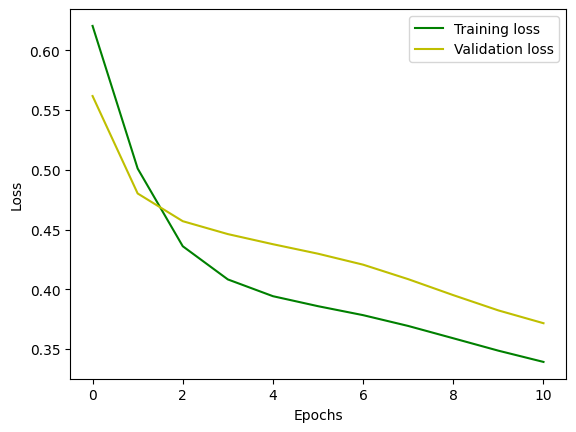

In [59]:
model_wrapper.plot_loss()

## Load model

In [70]:
import torch
model_bin = torch.load("./models/rev_directed_gat_with_pos_1.pt").cpu()

## Model back to CPU for evaluation purposes

In [17]:
# model = model_wrapper.get_model()
graph = graph.cpu()
model = model.cpu()

## Evaluation

In [18]:
# from dataAnalysis.Metrics import Evaluation

# y_dict = Evaluation.create_y_dict(model.predict(graph, test_mask), model.predict_proba(graph, test_mask) , graph.y[test_mask])
# y_dict_gw = Evaluation.create_y_dict(model.predict(graph, test_gw_mask), model.predict_proba(graph, test_gw_mask) , graph.y[test_gw_mask])

# Evaluation.plot_confusion_matrix_from_pred(model.predict(graph, test_mask), graph.y[test_mask])
# Evaluation.plot_confusion_matrix_from_pred(model.predict(graph, test_gw_mask), graph.y[test_gw_mask])
# Evaluation.get_df_metrics_from_pred(y_dict, y_dict_gw)

In [19]:
import sys
sys.path.insert(0, "./GraphSVX/")

In [71]:
import shap

explainer = shap.Explainer(model_bin)

ValueError: masker cannot be None.

In [44]:
from torch_geometric.explain import Explainer, ModelConfig, AttentionExplainer

model_config = ModelConfig(mode = "binary_classification", task_level = "node", return_type = "raw")
explainer = Explainer(model = model, algorithm = AttentionExplainer(), explanation_type = "model", model_config = {
    "mode":"binary_classification",
    "task_level":"node",
    "return_type":"raw",
}, node_mask_type = None,
                     edge_mask_type = "object")
explaination = explainer(graph.x, graph.edge_index)

KeyboardInterrupt: 

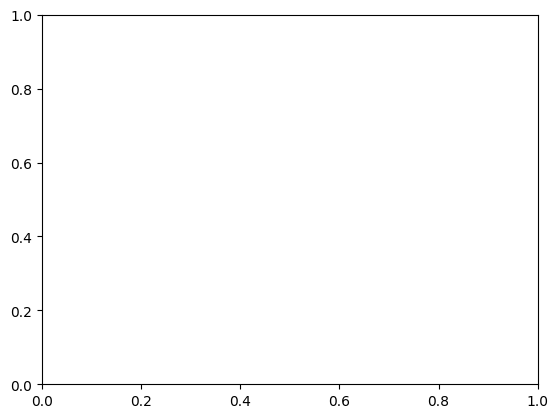

In [47]:
explaination.visualize_graph()

In [62]:
from GraphSVX.src.explainers import GraphSVX as Svx_explainer
explainer = Svx_explainer(graph.cpu(), model.cpu(), False)

In [64]:
explainer.explain(node_indexes=[3,4,5,6,7,8], num_samples = 1, info=False)

Explainations only consider node features


1it [00:21, 21.32s/it]


tensor([[6]])
tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5]])
compute_pred
tensor([1000.], dtype=torch.float64)
tensor([[1., 1., 1., 1., 1., 1.]])
tensor([0.0765])


1it [00:22, 22.36s/it]


tensor([[0],
        [2],
        [4]])
tensor([[1],
        [3],
        [5],
        [6]])
compute_pred
tensor([1000.], dtype=torch.float64)
tensor([[1., 1., 1., 1., 1.]])
tensor([0.2275])
Explainations only consider node features


...

1it [00:20, 20.30s/it]


tensor([[0]])
tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])
compute_pred
tensor([1000.], dtype=torch.float64)
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([0.1467])


1it [00:19, 19.73s/it]


tensor([[3]])
tensor([[0],
        [1],
        [2],
        [4],
        [5],
        [6]])
compute_pred
tensor([1000.], dtype=torch.float64)
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([0.1628])


[array([ 0.04584682,  0.00624223,  0.03374082, -0.00673345,  0.00806369,
        -0.01403517]),
 array([ 0.41757983, -0.01326751,  0.03686804, -0.12073112, -0.03317246]),
 array([-0.05578251,  0.10828368,  0.18945657,  0.01854879, -0.03549474]),
 array([-0.03649694, -0.02440168,  0.08363811,  0.05099551,  0.06762878,
        -0.02656362]),
 array([-0.04794473, -0.03141041, -0.05946199,  0.03369806,  0.08132417,
        -0.0683468 ,  0.0306458 ,  0.07464311,  0.05825917,  0.08110239,
         0.06032376]),
 array([-0.00160534,  0.00335462, -0.00219912, -0.00500809,  0.00135012,
         0.00150778,  0.01168217,  0.15336323,  0.00114746, -0.00250993])]

In [65]:
explainer.explain(node_indexes=[2], num_samples = 1, info=True)

Explainations only consider node features


1it [00:19, 19.14s/it]


tensor([[3],
        [5]])
tensor([[0],
        [1],
        [2],
        [4],
        [6]])
compute_pred
tensor([1000.], dtype=torch.float64)
tensor([[1., 1., 1., 1., 1.]])
tensor([0.0396])
WLS: Matrix not invertible
r2:  nan


/home/dwalke/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


TypeError: too many positional arguments

In [ ]:
explainer.explain(node_indexes=[2], num_samples = 8, info=False)

In [ ]:
data.iloc[-1][FEATURES]

In [ ]:
import numpy as np
np.sum([ 0.22138498,  0.05689339, -0.08460653,  0.66812375,  0.1837614 ,
         0.04388704,  0.10778466, -0.05039564])

In [ ]:
out = model(graph.x, graph.edge_index)
pred = torch.sigmoid(out)

In [30]:
pred

tensor([[0.3382],
        [0.0723],
        [0.0381],
        ...,
        [0.0621],
        [0.2537],
        [0.5204]], grad_fn=<SigmoidBackward0>)

In [25]:
np.sum([ 0.00369678,  0.01149082,  0.00580798,  0.04260477, -0.00313208,
         0.00202437,  0.02007359])

0.08256622999999999